In [1]:
import importlib
import sys
sys.path.append("../../")
from src.utils import utils as u
# import method_utils  # your module
from src.preprocessing import pipeline as pp
importlib.reload(u)

<module 'src.utils.utils' from '/aloy/home/ddalton/projects/scGPT_playground/notebooks/exp/../../src/utils/utils.py'>

In [3]:

def get_dsaids_w_umls()-> set:
    """
    Get a set of DO IDs that have UMLS codes associated with them.
    """
    dsaids = set()

    return dsaids


do_g = u.load_do_graph()

umls_2_doid = u.get_umls_2_doid_mapping(do_g)


# load DSAIDs
dsaids = u.get_processed_ids()
print(f"Nº of processed DSAIDs (for which we have all data): {len(dsaids)}")

# filter DSAIDs 

Nº of processed DSAIDs (for which we have all data): 7191


In [8]:
import numpy as np, pandas as pd, sys, os

clean_dsaids = u.get_clean_set_dsaids(["RNA-Seq"])

INFO:root:Loading signatures from file /aloy/home/ddalton/projects/disease_signatures/data/DiSignAtlas/signatures.pkl


Loaded Nº DSAIDs: 10306
Filter Human Species Nº DSAIDs: 7194
Filter RNA-seq & Microarray Nº DSAIDs: 2536
Filter DSAIDs with info Nº DSAIDs: 2534
Loaded signatures Nº DSAIDs: 2534


INFO:root:Nº of Human protein coding genes: 20608


Loaded human protein coding genes: 20608
Filter to enough Human protein coding genes Nº DSAIDs: 2533


In [ ]:
df_data_info = u.load_dsaid_df()

df_data_info.query("dsaid in @clean_dsaids", inplace=True)
print(f"Filtered DSAIDs: {len(df_data_info)}")  


Filtered DSAIDs: 2533


596

In [14]:
df_data_info

,dsaid,accession,platform,deg_count,disease,diseaseid,tissue,data_source,library_strategy,organism,control_case_sample_count,definition
3,DSA00004,GSE224022,GPL16791,1000,Retinoblastoma,C0035335,Retina,GEO,RNA-Seq,Homo sapiens,4|5,DO:A retinal cell cancer and malignant neoplas...
4,DSA00005,GSE126342,GPL11154,1000,Congenital Myotonic Dystrophy,C0410226,Skeletal muscle,GEO,RNA-Seq,Homo sapiens,9|11,MONDO:An inherited progressive disorder affect...
5,DSA00006,GSE126342,GPL11154,1000,Myotonic Dystrophy Type 1,C0027126,Skeletal muscle,GEO,RNA-Seq,Homo sapiens,6|16,DO:A myotonic disease that is characterized by...
14,DSA00015,GSE224056,GPL24676,1000,Gastric Cancer,C0699791,Stomach,GEO,RNA-Seq,Homo sapiens,4|5,DO:A gastrointestinal system cancer that is lo...
15,DSA00016,GSE224056,GPL24676,112,Gastric Cancer,C0699791,Stomach,GEO,RNA-Seq,Homo sapiens,5|5,DO:A gastrointestinal system cancer that is lo...
...,...,...,...,...,...,...,...,...,...,...,...,...
10150,DSA10151,GSE164397,GPL20301,579,Infantile Liver Failure,C3809522,Liver,GEO,RNA-Seq,Homo sapiens,2|22,MONDO:Any infantile liver failure in which the...
10155,DSA10156,GSE164485,GPL16791,39,COVID-19,D8888888,Brain,GEO,RNA-Seq,Homo sapiens,5|5,A Coronavirus infection that is characterized ...
10156,DSA10157,GSE164485,GPL16791,14,COVID-19,D8888888,Brain,GEO,RNA-Seq,Homo sapiens,8|10,A Coronavirus infection that is characterized ...
10175,DSA10176,GSE164799,GPL16791,1000,Cirrhosis,C1623038,Liver,GEO,RNA-Seq,Homo sapiens,5|4,MSH:Any pathological condition where fibrous c...


Filter by clean DSAIDs Nº DSAIDs: 2533
Filter by presence of UMLS codes Nº DSAIDs: 2421
Filter by mapping from UMLS to DOID Nº DSAIDs: 1607
Loaded 10306 DiSignAtlas metadata (external links)
Agreement of UMLS->DOIDs with external link DOIDs: 1590/1602 (99.25%)
Nº of DSAIDs w/ no UMLS->DOID but with DOID mapping: 475/814
Nº of DSAIDs w/ no UMLS->DOID but with DOID unique mapping: 350/814


Text(0.5, 0, 'Nº of DOIDs mapped to DSAID')

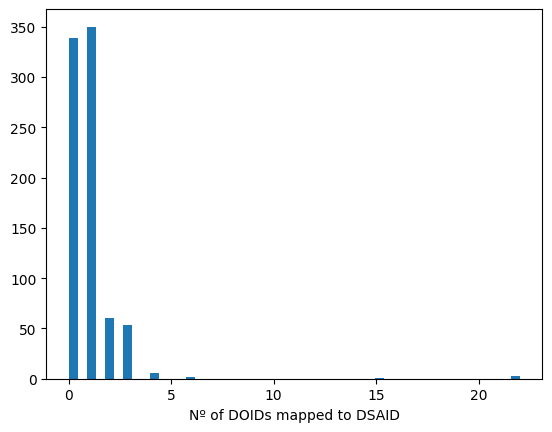

In [16]:
umls_2_doid = u.get_umls_2_doid_mapping(do_g)
df_data_info = u.load_dsaid_df()

# filter by clean dsaids
df_data_info = df_data_info[df_data_info["dsaid"].isin(clean_dsaids)]
print(f"Filter by clean DSAIDs Nº DSAIDs: {len(df_data_info)}")

# filter by presence of UMLS codes
df_data_info.dropna(subset=["diseaseid"], inplace=True)
print(f"Filter by presence of UMLS codes Nº DSAIDs: {len(df_data_info)}")

# filter by mapping from UMLS to DOID
df_data_no_do = df_data_info[~df_data_info["diseaseid"].isin(umls_2_doid.keys())]
df_data_info = df_data_info[df_data_info["diseaseid"].isin(umls_2_doid.keys())]
print(f"Filter by mapping from UMLS to DOID Nº DSAIDs: {len(df_data_info)}")

df_data_info["doid"] = df_data_info["diseaseid"].apply(lambda x: umls_2_doid.get(x, []))

dsaid_2_doid = u.get_dsaid_2_doid_mapping()

# Check
# 1. Agreement of UMLS->DOIDs w/ external link DOIDs
agreement_doids = []
for i, row in df_data_info.iterrows():
    dsaid_i = row["dsaid"]
    doid_i_1 = row["doid"]
    doid_i_2 = dsaid_2_doid.get(dsaid_i, [])
    if len(doid_i_2)>0:
        if len(set([doid_i_1]) & set(doid_i_2)) > 0:
            agreement_doids.append(True)
        else:
            agreement_doids.append(False)

agreement_doids = np.array(agreement_doids)
print(f"Agreement of UMLS->DOIDs with external link DOIDs: {np.sum(agreement_doids)}/{len(agreement_doids)} ({np.mean(agreement_doids) * 100:.2f}%)")
    

# 2. If we can "rescue" DSAIDs that have no UMLS codes but do have DOID mapping
_dsaids = df_data_no_do["dsaid"].to_list()
_doids_map = [dsaid_2_doid.get(dsaid, []) for dsaid in _dsaids]
print(f"Nº of DSAIDs w/ no UMLS->DOID but with DOID mapping: {len([d for d in _doids_map if len(d) >0])}/{len(_dsaids)}")
print(f"Nº of DSAIDs w/ no UMLS->DOID but with DOID unique mapping: {len([d for d in _doids_map if len(d) ==1])}/{len(_dsaids)}")
import matplotlib.pyplot as plt
plt.hist([len(d) for d in _doids_map], bins=50)
plt.xlabel("Nº of DOIDs mapped to DSAID")

In [ ]:
df_data_info["doid"] = df_data_info["diseaseid"].apply(lambda x: umls_2_doid[x])



In [38]:
len([d for d, c in df_data_info.groupby("doid")["accession"].count().items() if c > 1])

203

In [65]:

# Build UMLS CUI → DOID mapping
umls_2_doid = {}
i=0
for node_id, data in do_g.nodes(data=True):
    xrefs = data.get('xref', [])
    print(xrefs)

    if i == 50:
        break
    i+=1
    for ref in xrefs:

        if ref.startswith('UMLS_CUI:'):
            umls_cui = ref.split(':', 1)[1]
            if umls_cui not in umls_2_doid:

                umls_2_doid[umls_cui] = list()
            umls_2_doid[umls_cui].append(node_id)


# check no UMLS mapping to multiple DOIDs
_problem_cases = [(k, v) for k, v in umls_2_doid.items() if len(v) > 1]
assert len(_problem_cases) == 0, f"Found UMLS CUI with multiple DOIDs: {_problem_cases}"

# clean mapping
umls_2_doid = {k: v[0] for k, v in umls_2_doid.items() if len(v) == 1}
# return umls_2_doid

['ICDO:9120/3', 'MESH:D006394', 'NCI:C3088', 'NCI:C9275', 'SNOMEDCT_US_2023_03_01:39000009', 'UMLS_CUI:C0018923', 'UMLS_CUI:C0854893']
['UMLS_CUI:C0033999']
['ICD10CM:E88.9', 'ICD9CM:277.9', 'MESH:D008659', 'NCI:C3235', 'SNOMEDCT_US_2023_03_01:75934005', 'UMLS_CUI:C0025517']
[]
['SNOMEDCT_US_2023_03_01:293586001', 'UMLS_CUI:C0004058']
['SNOMEDCT_US_2023_03_01:294499007', 'UMLS_CUI:C0571411']
['SNOMEDCT_US_2023_03_01:294505008', 'UMLS_CUI:C0571417']
['SNOMEDCT_US_2023_03_01:294551009', 'UMLS_CUI:C0571463']
['SNOMEDCT_US_2023_03_01:293867002', 'UMLS_CUI:C0570787']
[]
['ICD10CM:Z88.1']
['SNOMEDCT_US_2023_03_01:293722000', 'UMLS_CUI:C0570646']
['ICD10CM:Z88.4']
['SNOMEDCT_US_2023_03_01:293865005', 'UMLS_CUI:C0570785']
['SNOMEDCT_US_2023_03_01:293869004', 'UMLS_CUI:C0570789']
['SNOMEDCT_US_2023_03_01:293653009', 'UMLS_CUI:C0570577']
[]
['SNOMEDCT_US_2023_03_01:91939003', 'UMLS_CUI:C0038757']
[]
[]
['SNOMEDCT_US_2023_03_01:293709008', 'UMLS_CUI:C0570633']
['SNOMEDCT_US_2023_03_01:295019008',

In [64]:
[(k,v) for k,v in umls_2_doid.items() if len(v) > 1]  # Show UMLS CUI with multiple DOIDs

[]

In [ ]:
    # # As additional QC we remove signatures with no DE genes
    # # Again these are some corner cases but which would add noise to the analysis
    # dsaids_to_remove_de = set()     
    # for dsaid_i, s_i in gene_signatures.items():
    #     adj_pval_i = np.array(s_i["adj_pval"])
    #     log_fc_i = np.array(s_i["log2FC"])

    #     # apply soft thresholds
    #     mask_de = (adj_pval_i < 0.05) & (np.abs(log_fc_i) > 1)
    #     n_de_genes = np.sum(mask_de)
    #     if n_de_genes < 10:
    #         dsaids_to_remove_de.add(dsaid_i)

    # gene_signatures = {k: v for k, v in gene_signatures.items() if k not in dsaids_to_remove_de}
    # df_data_info = df_data_info[df_data_info["dsaid"].isin(gene_signatures.keys())]
    # print(f"Filter to +10 DE genes Nº DSAIDs: {len(df_data_info)}")

    # # Return clean set of DSAIDs
    # return set(df_data_info["dsaid"].unique())

In [ ]:
# isolating function

# Load data

processed_ids = get_processed_ids()
logging.info(f"Nº of processed ids: {len(processed_ids)}")

df_data_info = pd.read_csv(data_info_path)

df_data_info_processed = df_data_info.copy()

df_data_info_processed = df_data_info_processed[
    df_data_info_processed["dsaid"].isin(processed_ids)
]

logging.info(f"Nº of processed ids in df_data_info: {len(df_data_info_processed)}")

df_data_info_processed_filtered = df_data_info_processed[
    (df_data_info_processed["organism"] == "Homo sapiens")
    & (
        (df_data_info_processed["library_strategy"] == "Microarray")
        | (df_data_info_processed["library_strategy"] == "RNA-Seq")
    )
]
logging.info(
    f"Nº of Filtered by library (filter out single cell): {df_data_info_processed_filtered.shape}"
)

# get all entrez protein-coding human ids
global human_entrez_protein_coding_ids

# Filter 1: Human Genes
human_dsaids = df_data_info_processed_filtered["dsaid"].to_list()

pct_thr = 0.5
# even though we have filtered by human, we now look at the actual genes! Some may not be human !
pct_human = list()
dsaids_f1 = list()
for i in range(len(signatures)):
    if signatures[i][0] in human_dsaids:
        _pct = len(
            set(signatures[i][2]).intersection(human_entrez_protein_coding_ids)
        ) / len(set(signatures[i][2]))
        pct_human.append(_pct)
        if _pct > pct_thr:
            dsaids_f1.append(signatures[i][0])
pct_human = np.array(pct_human)

df_data_info_processed_filtered = df_data_info_processed_filtered.copy()
df_data_info_processed_filtered["n_samples"] = [
    int(x.split("|")[1])
    for x in df_data_info_processed_filtered["control_case_sample_count"]
]

df_query = df_data_info_processed_filtered.query("dsaid in @dsaids_f1")

print(f"Nº of signatures: {len(df_query)}")
print(f"Nº of datasets : {len(df_query['accession'].unique())}")
print(f"Nº of diseases : {len(df_query['disease'].unique())}")
print(f"Nº of samples : {df_query['n_samples'].sum()}")

# Filter 2: Type of Sequencing
df_data_info_processed_filtered["library_strategy"].value_counts()
dsaids_f2 = dsaids_f1

# Filter 3: Presence of Disease Ontology IDs
# Leaf nodes Diseases
leaf_nodes = [
    node
    for node in do_G.nodes()
    if do_G.in_degree(node) == 0 and do_G.out_degree(node) > 0
]

dsaids_w_doids = [d for d in dsaids_f2 if d in dsaids_2_doids.keys()]
dsaids_w_diseases = [
    d for d in dsaids_w_doids if len(set(dsaids_2_doids[d]) & set(leaf_nodes)) > 0
]

# for now only take DSAIDS with 1 LEAF DISEASE!
dsaids_f3 = [
    d
    for d in dsaids_w_diseases
    if len(set(dsaids_2_doids[d]) & set(leaf_nodes)) == 1
]
print(f"Nº of DSAIDS with 1 leaf disease {len(dsaids_f3)}")

# Filter 3.1: Presence of Disease Ontology IDs
flatten = lambda l: [item for sublist in l for item in sublist]
df_query = df_data_info_processed_filtered.query("dsaid in @dsaids_w_doids")
print(f"Filtering 3.1 - has doid")
print(f"Nº of signatures: {len(df_query)}")
print(f"Nº of datasets : {len(df_query['accession'].unique())}")
print(f"Nº of diseases : {len(df_query['disease'].unique())}")
print(
    f"Nº of disease ontology ids: {len(set(flatten([dsaids_2_doids[x] for x in dsaids_w_doids])))}"
)
print(
    f"Nº of disease ontology diseases: {len(set(flatten([list(set(dsaids_2_doids[x])&set(leaf_nodes)) for x in dsaids_w_doids])))}"
)
print(f"Nº of samples : {df_query['n_samples'].sum()}")

# Filter 3.2: Presence of Leaf Disease Ontology IDs
df_query = df_data_info_processed_filtered.query("dsaid in @dsaids_w_diseases")
print(f"Filtering 3.2 - has doid leaf")
print(f"Nº of signatures: {len(df_query)}")
print(f"Nº of datasets : {len(df_query['accession'].unique())}")
print(f"Nº of diseases : {len(df_query['disease'].unique())}")
print(
    f"Nº of disease ontology ids: {len(set(flatten([dsaids_2_doids[x] for x in dsaids_w_diseases])))}"
)
print(
    f"Nº of disease ontology diseases: {len(set(flatten([list(set(dsaids_2_doids[x])&set(leaf_nodes)) for x in dsaids_w_diseases])))}"
)
print(f"Nº of samples : {df_query['n_samples'].sum()}")

# Filter 3.3: Presence of 1 Leaf Disease Ontology IDs
df_query = df_data_info_processed_filtered.query("dsaid in @dsaids_f3")
print(f"Filtering 3.3 - has 1 doid leaf")
print(f"Nº of signatures: {len(df_query)}")
print(f"Nº of datasets : {len(df_query['accession'].unique())}")
print(f"Nº of diseases : {len(df_query['disease'].unique())}")
print(
    f"Nº of disease ontology ids: {len(set(flatten([dsaids_2_doids[x] for x in dsaids_f3])))}"
)
print(
    f"Nº of disease ontology diseases: {len(set(flatten([list(set(dsaids_2_doids[x])&set(leaf_nodes)) for x in dsaids_f3])))}"
)
print(f"Nº of samples : {df_query['n_samples'].sum()}")

# Filter 4: Presence of DE Genes
f_signatures = [s for s in signatures if s[0] in dsaids_f3]
de_genes = process_map(get_de_genes, f_signatures, max_workers=8, chunksize=10)

# Filter 4.1: Presence of DE Genes
# Less than 50% of genes DE
# at least 50 DE genes
mask_de_genes = np.array(
    [(True if 0 <= len(d[0]) + len(d[1]) <= 1 * d[2] else False) for d in de_genes]
)

# get dsaids which pass filter
dsaids_f4 = np.array(dsaids_f3)[mask_de_genes]
print(f"Filtered by nº of DE genes: {len(dsaids_f4)}")

df_query = df_data_info_processed_filtered.query("dsaid in @dsaids_f4")
print(f"Filtering 4 - has 1 doid leaf")
print(f"Nº of signatures: {len(df_query)}")
print(f"Nº of datasets : {len(df_query['accession'].unique())}")
print(f"Nº of diseases : {len(df_query['disease'].unique())}")
print(
    f"Nº of disease ontology ids: {len(set(flatten([dsaids_2_doids[x] for x in dsaids_f4])))}"
)
print(
    f"Nº of disease ontology diseases: {len(set(flatten([list(set(dsaids_2_doids[x])&set(leaf_nodes)) for x in dsaids_f4])))}"
)
print(f"Nº of samples : {df_query['n_samples'].sum()}")

In [ ]:
import torch
import numpy as np
CLS = False  # Single-label classification
CLS_MULTILABEL = True  # Multilabel classification

output_values = np.array([[0,0,1],[1,0,0]])  # Placeholder for model output
celltype_labels = np.array([2,0])  # Placeholder for true labels


output_values = torch.tensor([[-10, -10, 20], [20, -10, 20]],dtype=torch.float32, device="cpu")  # Placeholder for model output
disease_multilabel = torch.tensor([[0, 0, 1], [1, 0, 1]],dtype=torch.float32, device="cpu")  # Placeholder for multilabel true labels
input_gene_ids = torch.tensor([[1, 0, 1], [0, 1, 1]])
total_error = 0
total_num = 0
predictions = []

loss_multilabel = torch.nn.BCEWithLogitsLoss(reduction="sum", weight=torch.tensor([]))  # Example weights for multilabel loss

if CLS:
    # Standard single-label accuracy
    accuracy = (output_values.argmax(1) == celltype_labels).sum().item()
    total_error += (1 - accuracy / len(input_gene_ids)) * len(input_gene_ids)
elif CLS_MULTILABEL:
    # Multilabel: compute sigmoid + threshold
    preds = torch.sigmoid(output_values).numpy()
    preds_bin = (preds > 0.5).astype(int)
    true = disease_multilabel.numpy()

    # Sample-wise accuracy: proportion of labels correctly predicted
    samplewise_acc = (preds_bin == true).mean(axis=1).mean()
    total_error += (1 - samplewise_acc) * len(input_gene_ids)
    
    print(loss_multilabel(output_values, disease_multilabel))
    
total_num += len(input_gene_ids)


print(total_error / total_num)

tensor(4.1223e-08)
0.0


In [142]:
disease_multilabel

tensor([[0., 0., 1.],
        [1., 0., 1.]])

In [ ]:
def get_pos_weight(y:np.array, max_cap=50.0, min_cap=1.0) -> torch.Tensor:
    """
    Compute positive weights for BCEWithLogitsLoss based on class imbalance.
    
    Args:
        y (torch.Tensor): Binary labels of shape (N, num_classes).
        max_cap (float): Maximum cap for the weights to avoid extreme imbalance.
        
    Returns:
        torch.Tensor: Positive weights for each class.
    """
    # convert numpy to torch tensor if needed
    if isinstance(y, np.ndarray):
        y = torch.tensor(y, dtype=torch.float32)

    # Count positives and negatives per label
    pos_counts = y.sum(dim=0)                  # (#labels,)
    neg_counts = y.shape[0] - pos_counts       # (#labels,)

    # Compute pos_weight = negatives / positives
    pos_weight = neg_counts / pos_counts.clamp(min=1)  # avoid division by zero



    # Cap the values to avoid extreme imbalance exploding gradients
    pos_weight = pos_weight.clamp(max=max_cap, min=min_cap)  

    return pos_weight


pos_weight = get_pos_weight(disease_multilabel.numpy())
print("pos_weight:", pos_weight)

# Use in BCEWithLogitsLoss
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='mean')




pos_weight: tensor([1., 2., 1.])


In [147]:
def get_pos_weight(target_batch):
    x=target_batch.sum(dim=0)
    out = target_batch*(target_batch.size(0)/x-1) #ratio of 1s to 0s, based on 0s set to weight of 1
    out[out==0]=1 #set all 0s to weight of 1
    out[torch.isnan(out)]=1 #this deals with the case when a batch has all zeros on that class
    return out


get_pos_weight(disease_multilabel)

tensor([[1., 1., 1.],
        [1., 1., 1.]])

In [ ]:
disease_multilabel.sum(dim=0)

tensor([1., 0., 2.])

: 

array([2, 0])

In [23]:
output_values.argmax(1)

array([2, 0])

In [7]:
import numpy as np
a = np.array([[1, 0, 1], [0, 1, 0], [1, 1, 0]])
b = np.array([[1, 0, 1], [0, 1, 0], [1, 0, 0]])

samplewise_acc = (a == b).mean(axis=1).mean()
(1 - samplewise_acc) * len(a)

0.3333333333333335

In [13]:
a = np.array([[1, 0, 1], [0, 1, 0], [1, 1, 0]])
b = np.array([[1, 0, 0], [0, 1, 0], [1, 0, 0]])

accuracy = (a.argmax(1) == b).sum().item()
total_error = (1 - accuracy / len(a)) * len(a)

print(total_error)

-2.0


In [17]:
(a.argmax(1) == b).sum().item()/len(a)

1.6666666666666667

In [8]:
samplewise_acc

0.8888888888888888